Read header and print it

In [1]:
from tttrkit.ptuio.reader import TTTRReader

# Linear scanner data
# reader = TTTRReader(r"C:\Users\dalibor\Documents\python\tttrkit\examples\data\250722_PPIX_freeALA_HEK_0J1.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Documents\python\tttrkit\examples\data\250722_Free_ALA_HEK_0J1.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Data\2025-06-18_Infinity_FLIM_test_data\MultiHarp150_2025-06-18_16-33-24.274_f1_ch1_accu1_px500.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Data\2025-10-23_NADH_test\2025-10-23_NADH_test.sptw\U2OS_NADH4.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-17_Leica_Chromaslide\512px_speed400_la1_zoom1_bdi_1.ptu")
# reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-17_Leica_Chromaslide\512px_speed400_la1_zoom1_mono_1.ptu")

# Harmonic scanner data
# reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-13_Leica-grating\512px_zoom1_Speed400_mono_1.ptu")
reader = TTTRReader(r"C:\Users\dalibor\Data\2026-08-13_Leica-grating\512px_zoom1_Speed400_bidi_la81.ptu")

for key, value in reader.header.tags.items():
    print(f'{key}: {value}')

Measurement_SubMode = reader.header.tags.get("Measurement_SubMode")

if Measurement_SubMode<1:
    print("Not an image. You must set scanning configuration.")
else:
    ImgHdr_PixX = reader.header.tags.get("ImgHdr_PixX")
    ImgHdr_PixY = reader.header.tags.get("ImgHdr_PixY")

# This file is recorded in point mode - scanner information is not in the header, but the markers are recorded anyway

File_GUID: {2B10175F-6322-43FC-8C4B-6E3369C14534}
File_CreatingTime: 2026-08-13 15:11:36.484000
Measurement_SubMode: 0
File_Comment: 
TTResult_StopReason: 1
Fast_Load_End: <Empty>
CreatorSW_Name: SymPhoTime 64
CreatorSW_Version: 2.10
CreatorSW_SVNBuild: 5837
CreatorSW_Modules: 0
ImgHdr_Dimensions: 1
ImgHdr_Ident: 3
Measurement_Mode: 3
HW_Type: MultiHarp
HW_SerialNo: 1042963
HW_PartNo: 930043
HW_Version: 1.0
HW_ExternalRefClock: False
HW_RefClockSource: 0
MeasDesc_Offset: 0
HW_Modules: 2
HWModule_TypeCode[0]: 1010
HWModule_VersCode[0]: 16843021
HWModule_TypeCode[1]: 1000
HWModule_VersCode[1]: 17694989
HW_Markers: 4
HWMarkers_Enabled[0]: True
HWMarkers_RisingEdge[0]: True
HWMarkers_Enabled[1]: True
HWMarkers_RisingEdge[1]: False
HWMarkers_Enabled[2]: True
HWMarkers_RisingEdge[2]: False
HWMarkers_Enabled[3]: True
HWMarkers_RisingEdge[3]: False
HWMarkers_HoldOff: 0
HW_Features: 183
HW_BaseResolution: 9.999999960041972e-12
MeasDesc_BinningFactor: 4
MeasDesc_Resolution: 3.999999984016789e-11

Get some useful constants from the header

In [2]:
from tttrkit.ptuio.utils import estimate_tcspc_bins
import numpy as np

wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=10) # if buffer = 0, channel overflow can be expected


Read intensity trace and markers that are saved in .ptu file

In [3]:
from tttrkit.ptuio.reconstructor import TraceReconstructor
from tttrkit.ptuio.decoder import T3OverflowCorrector


corrector = T3OverflowCorrector(wraparound=wrap)

reconstructor = TraceReconstructor(
    start_time = 0,
    stop_time = 10,
    max_detector = 2,
    bin_width = 1e-5,
    sync_rate = repetition_rate,
    outputs = ['photon_count','markers'],
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()


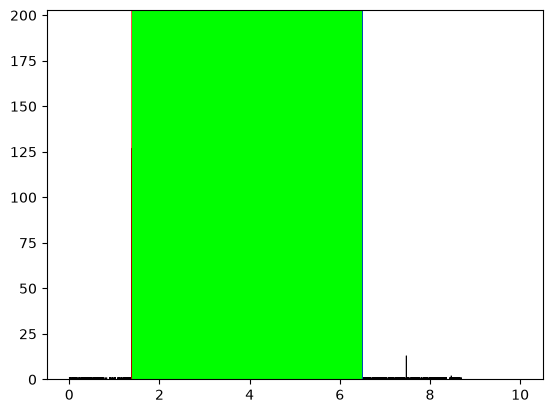

In [4]:
import matplotlib.pyplot as plt

time_axis = result.time
intensity = result.photon_count.isel(channel=0)


_,ax = plt.subplots(1,1)

ax.plot(time_axis,intensity,color='black',linewidth = .5)
ax.vlines(
    result.line_start_times,
    ymin=0,
    ymax=2*np.max(intensity),
    colors='red',
    linewidth=.5,
           )

ax.vlines(
    result.line_stop_times,
    ymin=0,
    ymax=2*np.max(intensity),
    colors='lime',
    linewidth=.5,
           )

ax.vlines(
    result.frame_start_times,
    ymin=0,
    ymax=2*np.max(intensity),
    colors='blue',
    linewidth=.5,
           )

ax.set_ylim(
    0,
    np.max(intensity),
)



plt.show()

In [5]:
# from tttrkit.ptuio.reconstructor import TraceReconstructor
# from tttrkit.ptuio.decoder import T3OverflowCorrector


# import ipywidgets as widgets
# from IPython.display import display
# import matplotlib.pyplot as plt

# # Use numeric inputs so the selected times are explicit.
# start_time_input = widgets.BoundedFloatText(
#     value=0.0, min=0.0, max=10.0, step=0.001,
#     description='Start Time (s):'
# )
# stop_time_input = widgets.BoundedFloatText(
#     value=10.0, min=0.0, max=10.0, step=0.001,
#     description='Stop Time (s):'
# )

# bin_width_input = widgets.FloatText(
#     value=1e-4,
#     description='Bin Width (s):',
#     step=1e-6
# )

# show_markers_checkbox = widgets.Checkbox(
#     value=True,
#     description='Show Markers'
# )

# apply_button = widgets.Button(
#     description='Apply & Reconstruct',
#     button_style='info'
# )

# output_area = widgets.Output()

# result = None

# def draw_plot():
#     """Redraw only the plot, including the selected-time guides."""
#     if result is None:
#         return
#     output_area.clear_output(wait=True)
#     with output_area:
#         intensity = result.photon_count.isel(channel=0)
#         y_max = max(2 * float(intensity.max()), 2)
#         fig, ax = plt.subplots(figsize=(12, 5))
#         ax.plot(result.time, intensity, color='black', linewidth=0.5)
#         ax.axvline(start_time_input.value, color='red', linestyle='--',
#                    linewidth=1, label='Selected start')
#         ax.axvline(stop_time_input.value, color='red', linestyle='--',
#                    linewidth=1, label='Selected stop')
#         if show_markers_checkbox.value and len(result.line_start_times) > 0:
#             ax.vlines(result.line_start_times, 0, y_max, colors='red', linewidth=0.5, label='Line Start')
#             ax.vlines(result.line_stop_times, 0, y_max, colors='lime', linewidth=0.5, label='Line Stop')
#             ax.vlines(result.frame_start_times, 0, y_max, colors='blue', linewidth=0.5, label='Frame Start')
#         ax.set_ylim(0, y_max)
#         ax.set_xlabel('Time (s)')
#         ax.set_ylabel('Photon Count')
#         ax.legend()
#         display(fig)
#         plt.close(fig)

# def on_apply_clicked(b):
#     global result
#     # The overflow corrector is stateful; use a new one for each full read.
#     corrector = T3OverflowCorrector(wraparound=wrap)
#     reconstructor = TraceReconstructor(
#         start_time=start_time_input.value,
#         stop_time=stop_time_input.value,
#         max_detector=2,
#         bin_width=bin_width_input.value,
#         sync_rate=repetition_rate,
#         outputs=['photon_count', 'markers'],
#     )
#     for chunk in reader.iter_chunks():
#         reconstructor.update(corrector.correct(chunk))
#     result = reconstructor.finalize()
#     draw_plot()

# # def on_time_changed(change):
# #     # This updates the red guide lines without rerunning reconstruction.
# #     draw_plot()

# apply_button.on_click(on_apply_clicked)
# # start_time_input.observe(on_time_changed, names='value')
# # stop_time_input.observe(on_time_changed, names='value')

# # Layout - plot on top, controls below
# controls = widgets.VBox([
#     start_time_input,
#     stop_time_input,
#     bin_width_input,
#     show_markers_checkbox,
#     apply_button
# ])

# widget_app = widgets.VBox([output_area, controls])
# display(widget_app)

# # Initial plot
# on_apply_clicked(None)

In [6]:
scan_period = np.mean(np.diff(result.line_start_times[:100]))
print("Scanning frequency [Hz]: ", 1/scan_period)
print("Scanning period [s]: ", scan_period)
line_duration = np.mean(np.array(result.line_stop_times[:100]-result.line_start_times[:100]))
print("Line duration [s]: ", line_duration)

# harmonic_duty_estimate = line_duration / scan_period * 2 # for mono-directional scan
harmonic_duty_estimate = line_duration / scan_period
print("Harmonic phase estimate: ",harmonic_duty_estimate)

Scanning frequency [Hz]:  800.0350021955263
Scanning period [s]:  0.0012499453114622637
Line duration [s]:  0.0008723016235773997
Harmonic phase estimate:  0.6978718313339062


Reconstruct only photon count (i.e., intensity) image

In [7]:
from tttrkit.ptuio.reconstructor import ScanConfig
from tttrkit.ptuio.reconstructor import ImageReconstructor

cfg = ScanConfig(
    bidirectional=True, 
    frames= 1,
    lines=512, 
    pixels=512, 
    line_accumulations= (8,),
    max_detector=2,
    bidirectional_phase_shift=-0.11,
    # marker_delay=0.1,
    harmonic_scan=True,
    laser_duty=harmonic_duty_estimate,
    line_start_marker_delay=0.02,
    line_stop_marker_delay=-0.02, # For our SP8 seems to be symmetrical
    )

reconstructor = ImageReconstructor(
        config=cfg, 
        tcspc_channels= tcspc_bins,
        outputs=['photon_count']
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()
image = result.photon_count


Reconstruction finished.


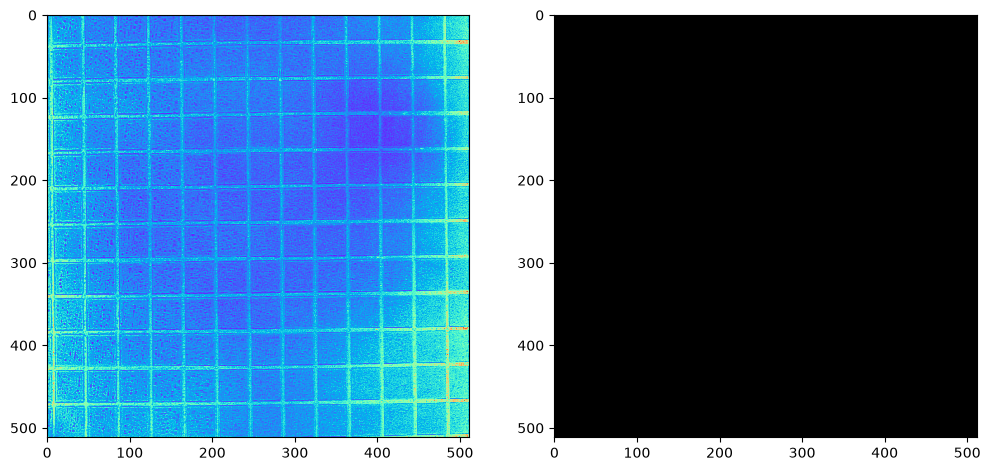

In [8]:
import matplotlib.pyplot as plt
image_slice = image.isel(frame=0,sequence=0,channel=0)
mask = image_slice>0

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(image_slice,cmap='rainbow',interpolation='nearest')
ax[1].imshow(mask,interpolation='nearest',cmap='gray') # just to see edges

plt.show()



Plot applied harmonic correction

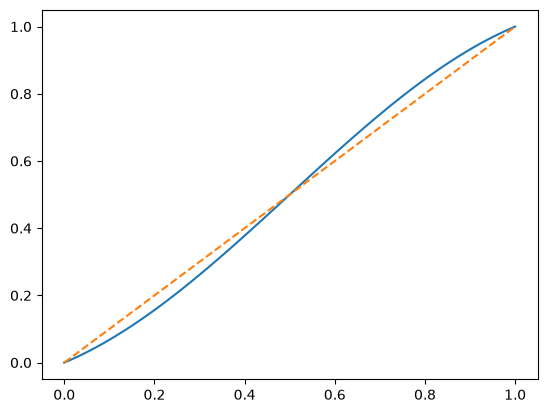

In [9]:
phase = np.linspace(0,1,100)
correction = reconstructor._harmonic_correction(phase)

fig, ax = plt.subplots()
ax.plot(phase,correction)
ax.plot(phase,phase,linestyle='--')
plt.show()
